In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# NETCDF4

__netcdf4__ is the engine used to handle _.nc_ files.

In [2]:
!pip install netcdf4 h5netcdf dask

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 91.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 96.5 MB/s eta 0:00:00


In [4]:
import os
import xarray as xr
import glob

weather_path = '/content/drive/MyDrive/Datasets/WEDS - RiskScore/weather_data_w/'
fire_path = '/content/drive/MyDrive/Datasets/WEDS - RiskScore/fire_data/'

wf_pattern = weather_path + 'era5_*.nc'
ff_pattern = fire_path + 'cams_*.nc'

if os.path.exists(weather_path):
    files = glob.glob(wf_pattern)
    if files:
        print(f'<SUCCESS> Found {len(files)} file(s).')
    else:
        print('<WARNING> Empty directory.')
else:
    print('<WARNING> Path does not exist.')

if os.path.exists(fire_path):
  files = glob.glob(ff_pattern)
  if files:
    print(f'<SUCCESS> Found {len(files)} file(s).')
  else:
    print('<WARNING> Empty directory.')
else:
  print('<WARNING> Path does not exist')

raw_wds = xr.open_mfdataset(
    wf_pattern,
    combine='by_coords',
    engine='h5netcdf'
)

if 'time' in raw_wds.dims:
    raw_wds = raw_wds.squeeze('time')

w_ds = raw_wds.resample(valid_time='1D').mean()

raw_fds = xr.open_mfdataset(
    ff_pattern,
    engine='h5netcdf',
)

f_ds = raw_fds

print("Daily weather Dataset:")
print(w_ds)

print("Daily fire Dataset:")
print(f_ds)

<SUCCESS> Found 6 file(s).
<SUCCESS> Found 1 file(s).
Daily weather Dataset:
<xarray.Dataset> Size: 223MB
Dimensions:     (valid_time: 184, latitude: 151, longitude: 401)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 1kB 2025-05-01 ... 2025-10-31
  * latitude    (latitude) float64 1kB 50.0 49.9 49.8 49.7 ... 35.2 35.1 35.0
  * longitude   (longitude) float64 3kB -10.0 -9.9 -9.8 -9.7 ... 29.8 29.9 30.0
    number      int64 8B 0
Data variables:
    t2m         (valid_time, latitude, longitude) float32 45MB dask.array<chunksize=(1, 51, 134), meta=np.ndarray>
    d2m         (valid_time, latitude, longitude) float32 45MB dask.array<chunksize=(1, 51, 134), meta=np.ndarray>
    sp          (valid_time, latitude, longitude) float32 45MB dask.array<chunksize=(1, 51, 134), meta=np.ndarray>
    u10         (valid_time, latitude, longitude) float32 45MB dask.array<chunksize=(1, 51, 134), meta=np.ndarray>
    v10         (valid_time, latitude, longitude) float32 45MB dask.array<chunksi

In [5]:
import numpy as np
import xarray as xr

# 1. Unifichiamo i chunk temporali per evitare il ValueError sulla finestra mobile
w_ds = w_ds.chunk({'valid_time': -1})

# 2. Calcolo Feature Meteo Istantanee
temp_c = w_ds['t2m'] - 273.15
dew_c = w_ds['d2m'] - 273.15
es = 6.112 * np.exp((17.67 * temp_c) / (temp_c + 243.5))
e = 6.112 * np.exp((17.67 * dew_c) / (dew_c + 243.5))
w_ds['rh'] = ((e / es) * 100).clip(0, 100)
w_ds['temp_c'] = temp_c

# 3. Calcolo Medie Settimanali (con min_periods=1 per non perdere i primi giorni)
w_ds['avgw_rh'] = w_ds['rh'].rolling(valid_time=7, center=False, min_periods=1).mean()
w_ds['avgw_temp'] = w_ds['temp_c'].rolling(valid_time=7, center=False, min_periods=1).mean()

# 4. Calcolo Differenze (Delta) rispetto a ieri
w_ds['temp_delta'] = w_ds['temp_c'].diff(dim='valid_time', n=1)
w_ds['rh_delta'] = w_ds['rh'].diff(dim='valid_time', n=1)

# 5. Pulizia, Rinomina e Allineamento
w_ds = w_ds.rename({
    't2m': 'temp_k',
    'sp': 'pressure'
})

f_ds = f_ds.rename({
    'cofire': 'smoke_index',
    'frpfire': 'fire_intensity'
})

# wind feature
w_ds['wind_speed'] = np.sqrt(w_ds['u10']**2 + w_ds['v10']**2)

w_ds['wind_dry_factor'] = w_ds['wind_speed'] / (w_ds['rh'] + 1)

print("<SUCCESS> Successfully initialized features.\n")

f_ds = f_ds.interp_like(w_ds, method='nearest')
print('<SUCCESS> Dataset successfully aligned.\n')

# 6. Merge Finale
ds = xr.merge([w_ds, f_ds])

print("Merged Dataset con Feature Estese:")
print(ds)

<SUCCESS> Successfully initialized features.

<SUCCESS> Dataset successfully aligned.

Merged Dataset con Feature Estese:
<xarray.Dataset> Size: 668MB
Dimensions:          (latitude: 151, longitude: 401, valid_time: 184)
Coordinates:
  * latitude         (latitude) float64 1kB 50.0 49.9 49.8 ... 35.2 35.1 35.0
  * longitude        (longitude) float64 3kB -10.0 -9.9 -9.8 ... 29.8 29.9 30.0
  * valid_time       (valid_time) datetime64[ns] 1kB 2025-05-01 ... 2025-10-31
    number           int64 8B 0
Data variables: (12/15)
    temp_k           (valid_time, latitude, longitude) float32 45MB dask.array<chunksize=(184, 51, 134), meta=np.ndarray>
    d2m              (valid_time, latitude, longitude) float32 45MB dask.array<chunksize=(184, 51, 134), meta=np.ndarray>
    pressure         (valid_time, latitude, longitude) float32 45MB dask.array<chunksize=(184, 51, 134), meta=np.ndarray>
    u10              (valid_time, latitude, longitude) float32 45MB dask.array<chunksize=(184, 51, 134), me

# DataFrame Creation

There is performed the task to create and polish the dataframe.

In [6]:
df = ds.to_dataframe().reset_index()

In [7]:
FEATURES = ['temp_c', 'rh', 'pressure', 'smoke_index', 'fire_intensity', 'avgw_temp', 'avgw_rh', 'temp_delta', 'rh_delta']

df = df.dropna(subset=FEATURES)

df['target'] = (df['fire_intensity'] > 1e-9).astype(int)

print(f"Dataset has {len(df)} rows.")
print(df[FEATURES + ['target']].head())

Dataset has 6460266 rows.
          temp_c         rh       pressure  smoke_index  fire_intensity  \
93473  16.805939  74.840469  101126.437500          0.0             0.0   
93474  14.880341  80.304665  100789.023438          0.0             0.0   
93475  10.704163  66.738037  101176.851562          0.0             0.0   
93476   9.810547  66.897202  101434.882812          0.0             0.0   
93477  10.644440  64.278038  101771.570312          0.0             0.0   

       avgw_temp    avgw_rh  temp_delta   rh_delta  target  
93473  18.726700  63.146378   -3.841522  23.388184       0  
93474  17.444580  68.865807   -1.925598   5.464195       0  
93475  15.759476  68.333862   -4.176178 -13.566628       0  
93476  14.569690  68.046532   -0.893616   0.159164       0  
93477  13.915482  67.418449    0.833893  -2.619164       0  


## DataFrame Info

Run the following code cell to obtain info about the dataset.

In [ ]:
stats = df[FEATURES].describe()
print(stats)

             temp_c            rh      pressure   smoke_index  fire_intensity  \
count  6.460266e+06  6.460266e+06  6.460266e+06  6.460266e+06    6.460266e+06   
mean   1.861956e+01  6.366363e+01  9.595338e+04  3.713688e-11    8.284916e-04   
std    6.057525e+00  1.595336e+01  4.506819e+03  4.470778e-09    9.547393e-02   
min   -1.050623e+01  9.224012e+00  6.993941e+04  0.000000e+00    0.000000e+00   
25%    1.436737e+01  5.274035e+01  9.333307e+04  0.000000e+00    0.000000e+00   
50%    1.878876e+01  6.491658e+01  9.713044e+04  0.000000e+00    0.000000e+00   
75%    2.315051e+01  7.574616e+01  9.945650e+04  0.000000e+00    0.000000e+00   
max    3.748877e+01  9.995325e+01  1.035693e+05  2.969538e-06    6.192098e+01   

          avgw_temp       avgw_rh    temp_delta      rh_delta  
count  6.460266e+06  6.460266e+06  6.460266e+06  6.460266e+06  
mean   1.868649e+01  6.342896e+01 -1.755449e-02  9.201563e-02  
std    5.704540e+00  1.384712e+01  1.755724e+00  9.024501e+00  
min   -7.36410

In [ ]:
comparison = df.groupby('target')[FEATURES].mean()
print("Medie comparate:")
print(comparison)

Medie comparate:
           temp_c         rh      pressure   smoke_index  fire_intensity  \
target                                                                     
0       18.611385  63.679466  95951.578125  0.000000e+00        0.000000   
1       22.536314  56.079315  96836.007812  1.778987e-08        0.396876   

        avgw_temp    avgw_rh  temp_delta  rh_delta  
target                                              
0       18.678350  63.445385   -0.017129  0.088051  
1       22.575182  55.579739   -0.220724  1.987423  


In [ ]:
counts = df['target'].value_counts()
percentages = df['target'].value_counts(normalize=True) * 100

print(f"Righe senza incendio (0): {counts[0]} ({percentages[0]:.2f}%)")
print(f"Righe con incendio (1):    {counts[1]} ({percentages[1]:.2f}%)")

Righe senza incendio (0): 6446780 (99.79%)
Righe con incendio (1):    13486 (0.21%)


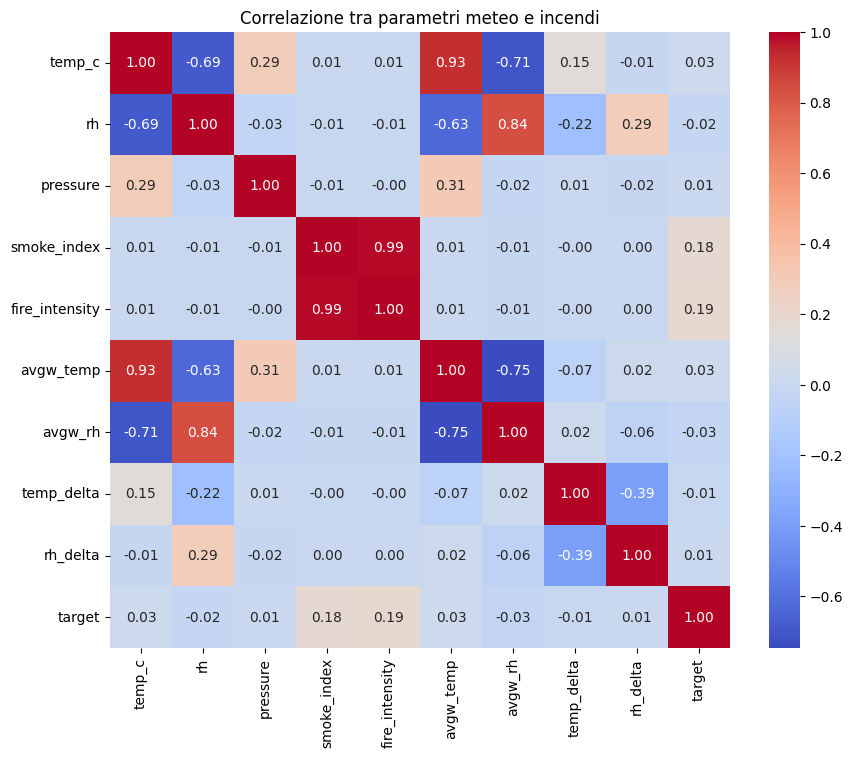

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
correlation_matrix = df[FEATURES + ['target']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlazione tra parametri meteo e incendi")
plt.show()

## Data Splitting

In [8]:
!pip install tensorflow

In [9]:
import numpy as np
from sklearn.model_selection import train_test_split

features = ['temp_c', 'rh', 'pressure', 'avgw_temp', 'avgw_rh', 'temp_delta', 'rh_delta']
X = df[features]
y = df['target']

""" 60% train, 20% validation, 20% test """
# stratify=y makes the split omogenous wrt y so 'target' this is necessary due to data imbalance.
X_train, X_remain, y_train, y_remain = train_test_split(X, y, test_size=0.40, stratify=y, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_remain, y_remain, test_size=0.50, stratify=y_remain, random_state=42)

print(f"<SUCCESS> Dataset successfully splitted.\n\nTraining set: {len(X_train)} rows.\nValidation set: {len(X_val)} rows.\nTest set: {len(X_test)} rows.")

<SUCCESS> Dataset successfully splitted.

Training set: 3876159 rows.
Validation set: 1292053 rows.
Test set: 1292054 rows.


## Statistics

### Temperature Distribution

The following cell create a plot which make it possible to visualize the temperature distribution with respect to fire or no fire.

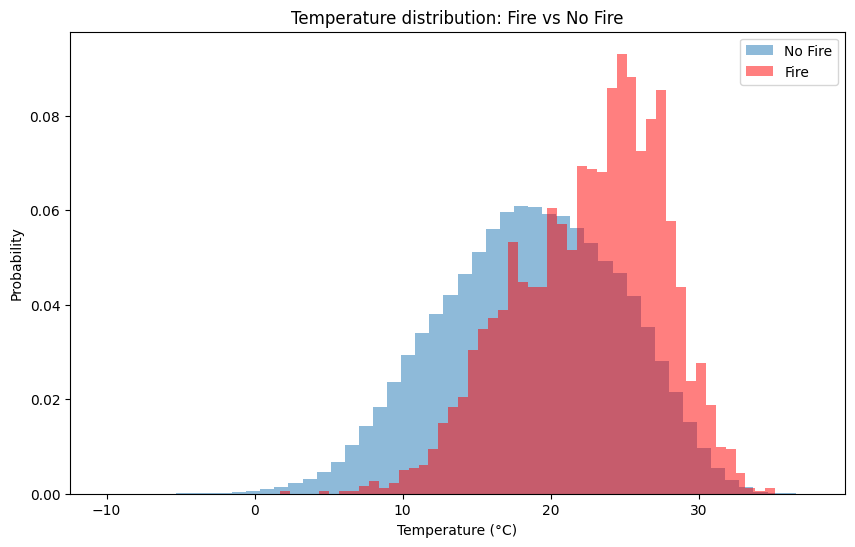

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

temp_no_fire = X_val[y_val == 0]['temp_c']
temp_fire = X_val[y_val == 1]['temp_c']

# Creiamo l'istogramma
plt.hist(temp_no_fire, bins=50, alpha=0.5, label='No Fire', density=True)
plt.hist(temp_fire, bins=50, alpha=0.5, label='Fire', color='red', density=True)

plt.xlabel('Temperature (°C)')
plt.ylabel('Probability')
plt.title('Temperature distribution: Fire vs No Fire')
plt.legend()
plt.show()

### Temperature vs Humidity

Here is visualized the relation between temperature and humidity in presence of fire.

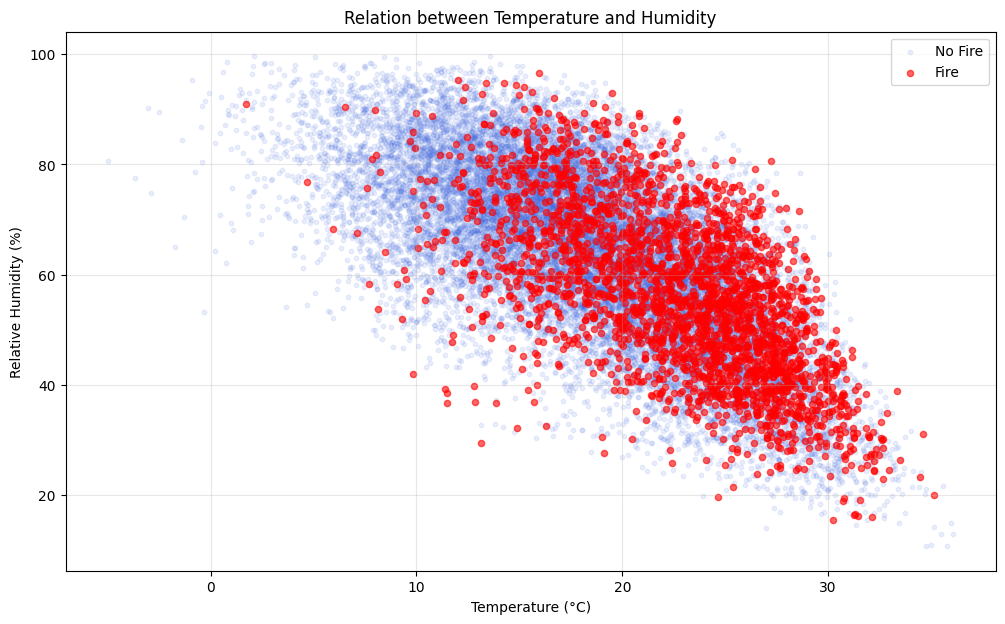

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

df_no_fire = X_val[y_val == 0].sample(20000, random_state=42)
df_fire = X_val[y_val == 1]

plt.scatter(df_no_fire['temp_c'], df_no_fire['rh'],
            color='royalblue', alpha=0.1, s=10, label='No Fire')

plt.scatter(df_fire['temp_c'], df_fire['rh'],
            color='red', alpha=0.6, s=20, label='Fire')

plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Relation between Temperature and Humidity')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Data Normalization

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("<SUCCESS> Dataset successfully normalized.\n")

<SUCCESS> Dataset successfully normalized.



# Model

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models

model_v1 = models.Sequential([
    # Opzione 1: Definiamo l'input usando uno strato dedicato (più moderno)
    layers.Input(shape=(X_train_scaled.shape[1],)),

    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    # Primo strato denso
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),

    # Hidden Layers
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),

    # Output Layer
    layers.Dense(1, activation='sigmoid')
])

# Compilazione
model_v1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model_v1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,121 (20.00 KB)

 Trainable params: 5,057 (19.75 KB)

 Non-trainable params: 64 (256.00 B)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_precision_model(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Primo blocco: Espansione e Normalizzazione
        layers.Dense(128),
        layers.LeakyReLU(negative_slope=0.01), # Più robusto della ReLU
        layers.BatchNormalization(),

        # Secondo blocco: Contrazione (Bottleneck)
        layers.Dense(64),
        layers.LeakyReLU(negative_slope=0.01),
        layers.Dropout(0.3), # Protezione dai falsi positivi

        layers.Dense(32),
        layers.LeakyReLU(negative_slope=0.01),
        layers.BatchNormalization(),

        # Terzo blocco: Fine-tuning
        layers.Dense(16, activation='relu'),

        # Output: Risk Score
        layers.Dense(1, activation='sigmoid')
    ])

    # Optimizer con Learning Rate ridotto per maggiore stabilità
    opt = tf.keras.optimizers.Adam(learning_rate=0.0001)

    model.compile(
        optimizer=opt,
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='pr_auc', curve='PR') # Focus sulla curva Precision-Recall
        ]
    )
    return model

# Crea il modello
model_v2 = build_precision_model((X_train_scaled.shape[1],))
model_v2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,545 (49.00 KB)

 Trainable params: 12,225 (47.75 KB)

 Non-trainable params: 320 (1.25 KB)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_precision_model(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Primo blocco: Espansione e Normalizzazione
        layers.Dense(128),
        layers.LeakyReLU(negative_slope=0.01), # Più robusto della ReLU
        layers.BatchNormalization(),

        # Secondo blocco: Contrazione (Bottleneck)
        layers.Dense(16),
        layers.LeakyReLU(negative_slope=0.01),

        layers.Dense(64),
        layers.LeakyReLU(negative_slope=0.01),
        layers.Dropout(0.3), # Protezione dai falsi positivi

        layers.Dense(32),
        layers.LeakyReLU(negative_slope=0.01),

        layers.Dense(32),
        layers.LeakyReLU(negative_slope=0.01),
        layers.BatchNormalization(),

        # Terzo blocco: Fine-tuning
        layers.Dense(16, activation='relu'),

        # Output: Risk Score
        layers.Dense(1, activation='sigmoid')
    ])

    # Optimizer con Learning Rate ridotto per maggiore stabilità
    opt = tf.keras.optimizers.Adam(learning_rate=0.0001)

    model.compile(
        optimizer=opt,
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='pr_auc', curve='PR') # Focus sulla curva Precision-Recall
        ]
    )
    return model

# Crea il modello
model_v3 = build_precision_model((X_train_scaled.shape[1],))
model_v3.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 16)             │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,753 (34.19 KB)

 Trainable params: 8,433 (32.94 KB)

 Non-trainable params: 320 (1.25 KB)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_precision_model(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Standard funnel - much cleaner for Backpropagation
        layers.Dense(512),
        layers.LeakyReLU(0.01),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(256),
        layers.LeakyReLU(0.01),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(128),
        layers.LeakyReLU(0.01),
        layers.BatchNormalization(),

        layers.Dense(64, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    # Optimizer con Learning Rate ridotto per maggiore stabilità
    opt = tf.keras.optimizers.Adam(learning_rate=0.0001)

    model.compile(
        optimizer=opt,
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='pr_auc', curve='PR') # Focus sulla curva Precision-Recall
        ]
    )
    return model

# Crea il modello
model_v4 = build_precision_model((X_train_scaled.shape[1],))
model_v4.summary()

NameError: name 'X_train_scaled' is not defined

In [29]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_precision_model(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Standard funnel - much cleaner for Backpropagation
        layers.Dense(512),
        layers.LeakyReLU(0.01),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(256),
        layers.LeakyReLU(0.01),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(512),
        layers.LeakyReLU(0.01),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(256),
        layers.LeakyReLU(0.01),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(128),
        layers.LeakyReLU(0.01),
        layers.BatchNormalization(),

        layers.Dense(64, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    # Optimizer con Learning Rate ridotto per maggiore stabilità
    opt = tf.keras.optimizers.Adam(learning_rate=0.001)

    model.compile(
        optimizer=opt,
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='pr_auc', curve='PR') # Focus sulla curva Precision-Recall
        ]
    )
    return model

# Crea il modello
model_v5 = build_precision_model((X_train_scaled.shape[1],))
model_v5.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 512)            │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 447,201 (1.71 MB)

 Trainable params: 443,873 (1.69 MB)

 Non-trainable params: 3,328 (13.00 KB)

## Specify model

In [30]:
model = model_v5

In [31]:
import numpy as np

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
total = neg + pos
weight_for_0 = (1 / neg) * (total / 2.0)
weight_for_1 = (1 / pos) * (total / 2.0)
class_weights = {0: weight_for_0, 1: weight_for_1}

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_pr_auc',
    patience=5,
    restore_best_weights=True,
    mode='max'
)

early_stop_prec = tf.keras.callbacks.EarlyStopping(
    monitor='val_pr_auc',
    patience=10,
    restore_best_weights=True,
    mode='max'
)

In [32]:
print("Starting training...")

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=1000,
    batch_size=8192,
    class_weight=class_weights,
    #callbacks=[early_stop_prec],
    verbose=1
)

Starting training...
Epoch 1/1000
474/474 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - loss: 0.6200 - pr_auc: 0.0045 - precision: 0.0037 - recall: 0.6985 - val_loss: 0.5740 - val_pr_auc: 0.0058 - val_precision: 0.0046 - val_recall: 0.6092
Epoch 2/1000
474/474 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.6069 - pr_auc: 0.0054 - precision: 0.0040 - recall: 0.6797 - val_loss: 0.6169 - val_pr_auc: 0.0059 - val_precision: 0.0041 - val_recall: 0.6626
Epoch 3/1000
474/474 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.6019 - pr_auc: 0.0057 - precision: 0.0039 - recall: 0.7025 - val_loss: 0.5674 - val_pr_auc: 0.0066 - val_precision: 0.0041 - val_recall: 0.7178
Epoch 4/1000
474/474 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.5993 - pr_auc: 0.0060 - precision: 0.0041 - recall: 0.6845 - val_loss: 0.6091 - val_pr_auc: 0.0066 - val_precision: 0.0041 - val_recall: 0.6770
Epoch 5/1000
474/474 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.5991 - pr_auc: 0.0060 - precision: 0.0041 - recall: 0.7000 - val_loss: 0.5598

In [33]:
results = model.evaluate(X_test_scaled, y_test, verbose=1)
print(f"AUC test: {results[2]:.4f}")

y_pred_prob = model.predict(X_test_scaled)

40377/40377 ━━━━━━━━━━━━━━━━━━━━ 117s 3ms/step - loss: 0.4047 - pr_auc: 0.0198 - precision: 0.0059 - recall: 0.6559
AUC test: 0.6559
40377/40377 ━━━━━━━━━━━━━━━━━━━━ 74s 2ms/step


In [34]:
# treshold to determine fire/nofire
y_pred = (y_pred_prob > 0.95).astype(int)

from sklearn.metrics import classification_report, confusion_matrix
print("\nConfusion Matrix:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1289357
           1       0.04      0.12      0.06      2697

    accuracy                           0.99   1292054
   macro avg       0.52      0.55      0.53   1292054
weighted avg       1.00      0.99      0.99   1292054



In [35]:
import joblib

# Save the scaler
joblib.dump(scaler, '/content/drive/MyDrive/Models/WEDS - RiskScore/data_scaler_v5_1000.pkl')

# Save the model
model_v5.save('/content/drive/MyDrive/Models/WEDS - RiskScore/fire_risk_model_v5_1000.keras')

print("<SUCCESS> Model saved as fire_risk_model_v4.keras")

<SUCCESS> Model saved as fire_risk_model_v4.keras


## Statistics

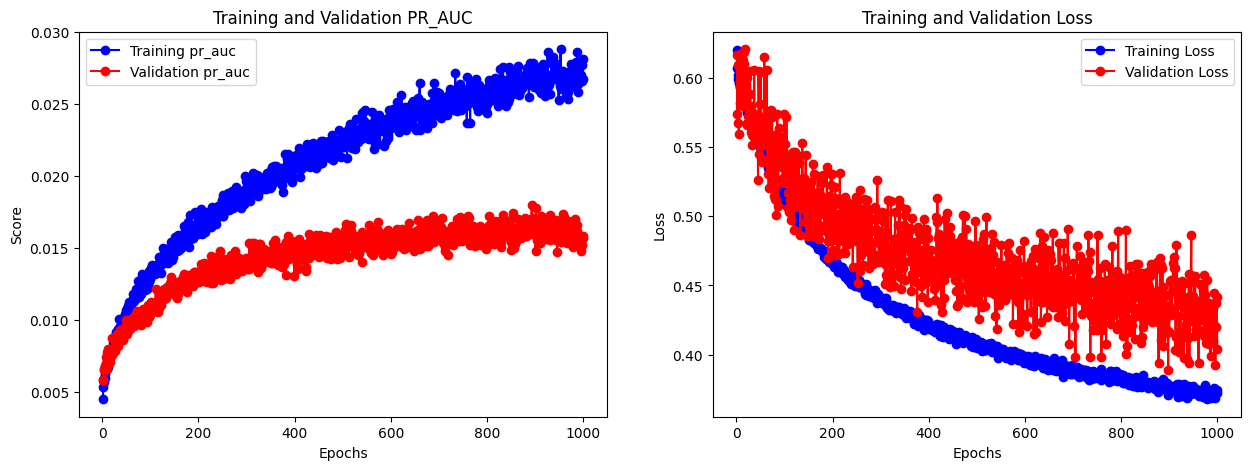

In [36]:
import matplotlib.pyplot as plt

def plot_learning_curves(history):
    # Verifichiamo i nomi delle chiavi (cambiano se hai usato 'auc' o 'pr_auc')
    keys = history.history.keys()

    # Cerchiamo la metrica AUC (che sia pr_auc o auc standard)
    auc_key = 'pr_auc' if 'pr_auc' in keys else 'auc'
    val_auc_key = 'val_pr_auc' if 'val_pr_auc' in keys else 'val_auc'

    acc = history.history[auc_key]
    val_acc = history.history[val_auc_key]
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(15, 5))

    # Grafico AUC
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label=f'Training {auc_key}')
    plt.plot(epochs, val_acc, 'ro-', label=f'Validation {auc_key}')
    plt.title(f'Training and Validation {auc_key.upper()}')
    plt.xlabel('Epochs')
    plt.ylabel('Score')
    plt.legend()

    # Grafico Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_learning_curves(history)

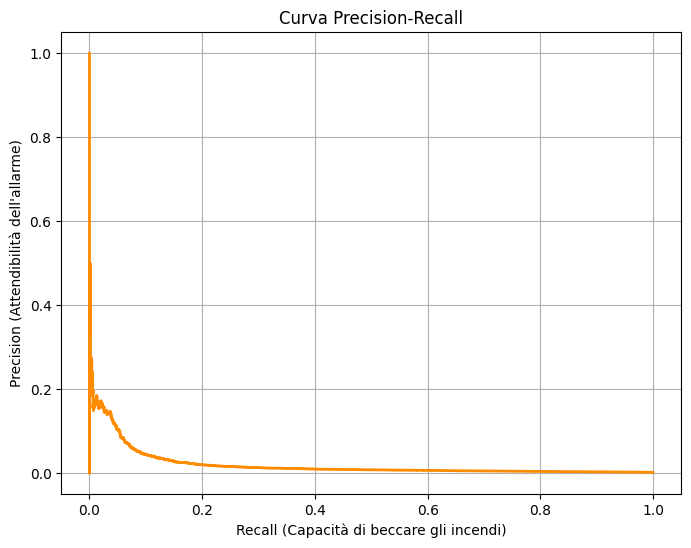

In [37]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='darkorange', lw=2)
plt.xlabel('Recall (Capacità di beccare gli incendi)')
plt.ylabel('Precision (Attendibilità dell\'allarme)')
plt.title('Curva Precision-Recall')
plt.grid(True)
plt.show()

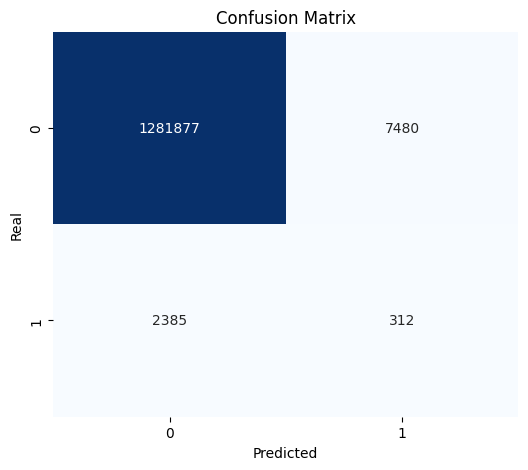

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Real')
plt.title('Confusion Matrix')
plt.show()

Generating predictions...
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


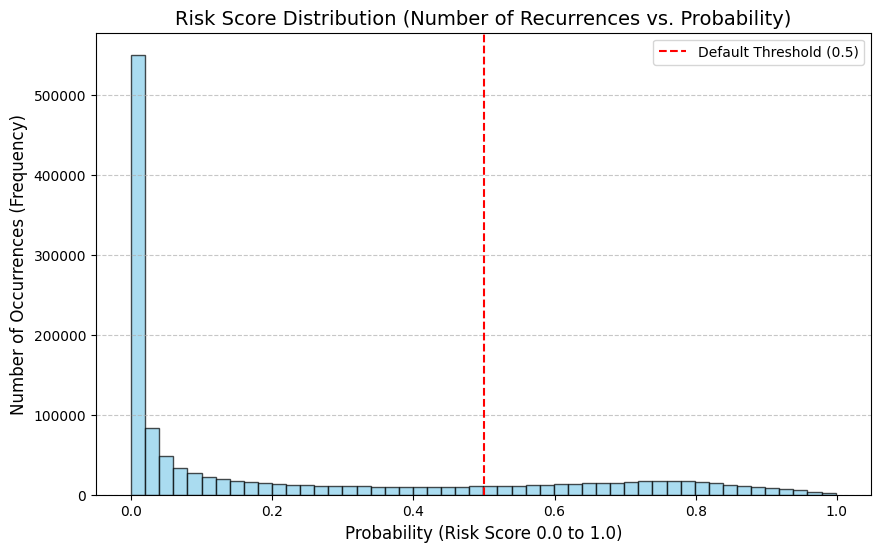

Mean Risk Score: 0.2300
Max Risk Score: 0.9984
Min Risk Score: 0.0000


In [39]:
import matplotlib.pyplot as plt
import numpy as np

def plot_probability_distribution(model, X_test_scaled):
    """
    Plots the recurrence (frequency) of each risk score probability.
    """
    # 1. Get raw Sigmoid outputs (values between 0 and 1)
    print("Generating predictions...")
    y_probs = model.predict(X_test_scaled, batch_size=8192).flatten()

    # 2. Create the plot
    plt.figure(figsize=(10, 6))

    # We use 50 bins to see the distribution in 2% increments
    counts, bins, patches = plt.hist(y_probs, bins=50, color='skyblue', edgecolor='black', alpha=0.7)

    # 3. Customizing the labels
    plt.title('Risk Score Distribution (Number of Recurrences vs. Probability)', fontsize=14)
    plt.xlabel('Probability (Risk Score 0.0 to 1.0)', fontsize=12)
    plt.ylabel('Number of Occurrences (Frequency)', fontsize=12)

    # Optional: Log scale if the 0.0 class (no fire) is so large it hides the others
    # plt.yscale('log')

    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # 4. Adding a vertical line for the standard 0.5 threshold
    plt.axvline(x=0.5, color='red', linestyle='--', label='Default Threshold (0.5)')
    plt.legend()

    plt.show()

    # Summary Statistics
    print(f"Mean Risk Score: {np.mean(y_probs):.4f}")
    print(f"Max Risk Score: {np.max(y_probs):.4f}")
    print(f"Min Risk Score: {np.min(y_probs):.4f}")

# Execute the function
plot_probability_distribution(model, X_test_scaled)

Calculating predictions...
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


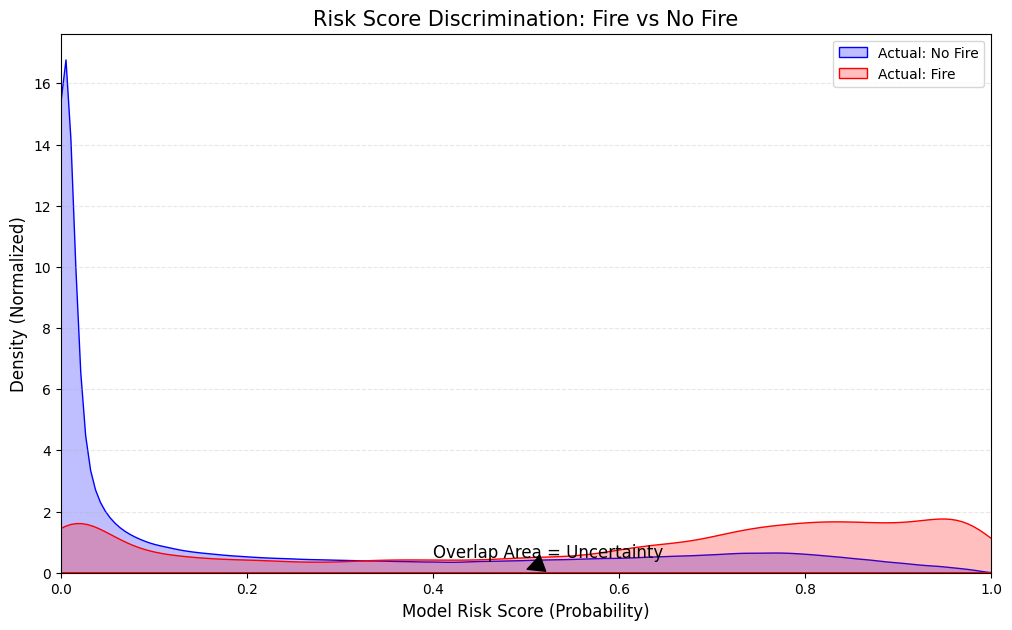

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_risk_separation(model, X_test_scaled, y_test):
    """
    Plots the distribution of Risk Scores separated by actual Fire / No Fire labels.
    """
    print("Calculating predictions...")
    y_probs = model.predict(X_test_scaled, batch_size=8192).flatten()

    plt.figure(figsize=(12, 7))

    # Create masks for the two classes
    fire_mask = (y_test == 1)
    no_fire_mask = (y_test == 0)

    # Plot Distribution for No Fire
    sns.kdeplot(y_probs[no_fire_mask],
                fill=True, color="blue", label="Actual: No Fire",
                bw_adjust=0.5, common_norm=False)

    # Plot Distribution for Fire
    sns.kdeplot(y_probs[fire_mask],
                fill=True, color="red", label="Actual: Fire",
                bw_adjust=0.5, common_norm=False)

    # Formatting
    plt.title('Risk Score Discrimination: Fire vs No Fire', fontsize=15)
    plt.xlabel('Model Risk Score (Probability)', fontsize=12)
    plt.ylabel('Density (Normalized)', fontsize=12)
    plt.xlim(0, 1) # Probability is always 0 to 1
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.legend()

    # Add descriptive text
    plt.annotate('Overlap Area = Uncertainty', xy=(0.5, 0.1), xytext=(0.4, 0.5),
                 arrowprops=dict(facecolor='black', shrink=0.05),
                 fontsize=12, color='black')

    plt.show()

# Run the plot
plot_risk_separation(model, X_test_scaled, y_test)

# TinyML

Then it is time to transform from a model to a tinyML model.


In [41]:
to_tiny_path = '/content/drive/MyDrive/Models/WEDS - RiskScore/tiny/'
version_number = 5_500

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

open(f"{to_tiny_path}fire_risk_tmodel_v{version_number}.tflite", "wb").write(tflite_model)


Saved artifact at '/tmp/tmpq0hneher'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 7), dtype=tf.float32, name='keras_tensor_32')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139978199158800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139978199163216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139978199165520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139978199162832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139978199167440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139978199166864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139978199164368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139978199166672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139978199167248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139978199168784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139978199168592: Tens

1767468

In [42]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT] # This enables quantization

tflite_quant_model = converter.convert()

# Save for Deployment
with open(f"{to_tiny_path}fire_risk_tmodel_quant_v{version_number}.tflite", "wb") as f:
    f.write(tflite_quant_model)

Saved artifact at '/tmp/tmpzb30z4hk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 7), dtype=tf.float32, name='keras_tensor_32')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139978199158800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139978199163216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139978199165520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139978199162832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139978199167440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139978199166864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139978199164368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139978199166672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139978199167248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139978199168784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139978199168592: Tens